# 00 - Data overview

Sanity-checks the dataset before running any effect analysis: how many
trials/users we have, what's collected per trial, and the closest
reproduction of the paper's Fig 3 (problems solved per user, and per
operation type).

See `../DATA_GAPS.md` for what the paper's Section 4 (User Demographics)
needs that this schema doesn't collect at all.


In [1]:
# Data source toggle. The live backend DB has zero trial_results as of
# 2026-09 (see ../DATA_GAPS.md) -- this app just went public. Flip
# USE_SYNTHETIC to False once real rows exist; every cell below is written
# against the DataFrame shape returned by moravec_analysis.data, so nothing
# else needs to change.
USE_SYNTHETIC = False

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from moravec_analysis.data import load_trial_results
from moravec_analysis.features import add_all_derived_fields, filter_rt_outliers
from moravec_analysis.synth import generate_synthetic_trials

if USE_SYNTHETIC:
    raw = generate_synthetic_trials(n_users=400, trials_per_user=150, seed=7)
else:
    raw = load_trial_results()  # defaults to apps/backend/data/moravec.sqlite

df = add_all_derived_fields(raw)
print(f"{len(df):,} trials, {df.email_hash.nunique():,} users")
df.head()


229 trials, 1 users


,id,email_hash,level_number,category_codename,operands,answer,correct,time_exceeded,time_taken,played_at,...,has_five,op1_gt_op2,unordered_pair,presented_pair,is_rhyme_pair,presented_in_rhyme_order,is_rhyme_control_pair,presented_in_control_order,table_distance_1,numeric_distance_le_2
0,b71489e4-4089-48fb-91c8-57018effab49,1bb8091170824093896f3bb9d158991b637d108c9b11ff...,1,1d+1d,"[5, 3]",8,True,False,1376,2026-09-02 14:20:30.456,...,True,True,"(3, 5)","(5, 3)",False,False,True,False,<NA>,<NA>
1,ff1c2b76-e8c9-4244-81d7-0bc393f456fa,1bb8091170824093896f3bb9d158991b637d108c9b11ff...,1,1d+1d,"[4, 6]",10,True,False,1384,2026-09-02 14:20:31.840,...,False,False,"(4, 6)","(4, 6)",True,False,False,False,<NA>,<NA>
2,e69af72d-ab35-434f-8cc6-083e1554cd64,1bb8091170824093896f3bb9d158991b637d108c9b11ff...,1,1d+1d,"[8, 5]",13,True,False,1581,2026-09-02 14:20:33.421,...,True,True,"(5, 8)","(8, 5)",False,False,False,False,<NA>,<NA>
3,e027f4db-5f97-4e4c-af89-ee8028b725cf,1bb8091170824093896f3bb9d158991b637d108c9b11ff...,1,1dx1d,"[9, 4]",36,True,False,2145,2026-09-02 14:20:35.566,...,False,True,"(4, 9)","(9, 4)",False,False,False,False,<NA>,<NA>
4,12772bbc-689d-4107-bb36-0092ee87088a,1bb8091170824093896f3bb9d158991b637d108c9b11ff...,1,1dx1d,"[7, 7]",49,True,False,1259,2026-09-02 14:20:36.825,...,False,False,"(7, 7)","(7, 7)",False,False,False,False,<NA>,<NA>


## Trials per user (paper's Fig 3, top panel)

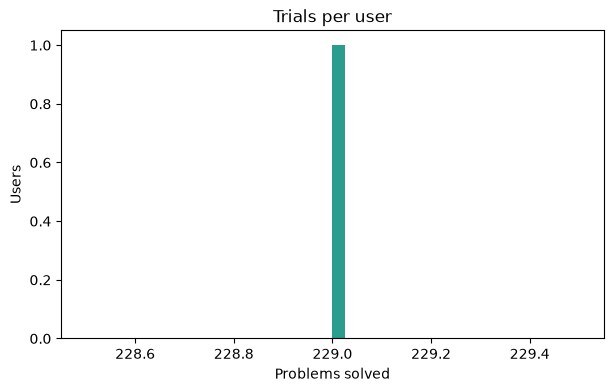

count      1.0
mean     229.0
std        NaN
min      229.0
25%      229.0
50%      229.0
75%      229.0
max      229.0
dtype: float64

In [2]:
per_user = df.groupby("email_hash").size()
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(per_user, bins=40, color="#2a9d8f")
ax.set_xlabel("Problems solved")
ax.set_ylabel("Users")
ax.set_title("Trials per user")
plt.show()
per_user.describe()


## Trials by operation type (paper's Fig 3, bottom panel)

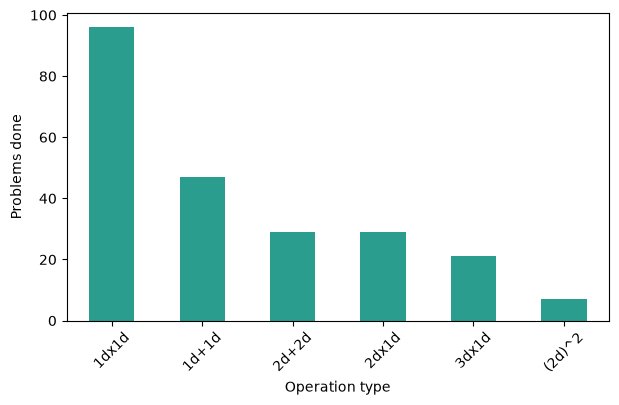

category_codename
1dx1d     96
1d+1d     47
2d+2d     29
2dx1d     29
3dx1d     21
(2d)^2     7
Name: count, dtype: int64

In [3]:
by_category = df["category_codename"].value_counts()
fig, ax = plt.subplots(figsize=(7, 4))
by_category.plot.bar(ax=ax, color="#2a9d8f")
ax.set_ylabel("Problems done")
ax.set_xlabel("Operation type")
plt.xticks(rotation=45)
plt.show()
by_category


## Level vs Practice split, correctness, hint usage

In [4]:
print(df["run_type"].value_counts(normalize=True))
print()
print("overall accuracy:", df["correct"].mean())
print("hint_shown rate:", df["hint_shown"].mean())
print()
print("date range:", df["played_at"].min(), "to", df["played_at"].max())


run_type
level       0.960699
practice    0.039301
Name: proportion, dtype: float64

overall accuracy: 0.9388646288209607
hint_shown rate: 0.0

date range: 2026-09-02 14:20:30.456000 to 2026-09-03 18:43:13.855000


## What's missing here

- **Demographics** (age, gender, education, country -- paper Section 4):
  not collected anywhere in the backend. `users` only has `email_hash`,
  `created_at`, `is_anonymous`. Any demographic breakdown or replication of
  the paper's participant table is impossible with the current schema.
- **Digit-erase / edit signal**: the paper excludes trials "in which
  participants erased a digit" from the RT analysis. We only store the
  final submitted `answer` and total `time_taken` -- no keystroke or edit
  history -- so that exclusion can't be reproduced; `filter_rt_outliers`
  (the 4-SD rule) is the only exclusion we can apply.
